# MNIST Digit Classifier from Scratch

***Written by Damian Toma. Strictly non-AI UGC.***

A feedforward neural network built with NumPy that classifies handwritten digits from the [MNIST dataset](http://yann.lecun.com/exdb/mnist/) without any deep learning frameworks.

## Architecture

```
Input (784) -> Dense (256) -> ReLU -> Dense (128) -> ReLU -> Dense (10) -> Softmax
```

The input is a flattened 28x28 grayscale image. The output is a probability distribution over the 10 digit classes (0-9).

## How It Works

- **Forward pass:** activations flow through layers via `A = XW + b`
- **Loss:** cross-entropy between predicted probabilities and one-hot labels
- **Backward pass:** gradients are backpropagated manually through each module
- **Update:** vanilla gradient descent (`W -= lr * dW`)

## Data

MNIST is downloaded automatically via `sklearn.datasets.fetch_openml`. It contains 70,000 labeled images, which I split into:

| Split | Size |
|-------|------|
| Train | 56,000 |
| Val   | 7,000 |
| Test  | 7,000 |

Pixel values are min-max normalized to [0, 1].

## Training

Default hyperparameters:

| Hyperparameter | Value |
|----------------|-------|
| Epochs         | 25    |
| Batch size     | 128   |
| Learning rate  | 0.01  |

## Requirements

```
numpy
matplotlib
scikit-learn
```

Install with:

```bash
pip install numpy matplotlib scikit-learn
```

## Usage

Run the notebook top to bottom. It will:

1. Download and preprocess MNIST
2. Define and initialize the network
3. Train for 25 epochs (~3mins), printing loss and accuracy each epoch
4. Plot the training loss curve
5. Display a 10x5 grid of test predictions (green = correct, red = incorrect)

In [1]:
# imports

import numpy as np
import random
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml  # for MNIST data
from abc import ABC, abstractmethod  # for abstract Module implementation

plt.style.use("dark_background")

In [2]:
# preprocessing

print(f"Downloading MNIST dataset...")
data = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')

X, y = data.data, data.target.astype(int)

print(f"{X.shape[0]:,.0f} black and white images with {X.shape[1]:,.0f} pixels each, (stored as {X.dtype})")
print(f"{y.shape[0]:,.0f} number labels (0-9) paired with each image (stored as {y.dtype})")
print(f"The first few images show the numbers: {y[:10]}")
print(f"\nBlack, White = {X[0].min()}, {X[0].max()}")

# min-max normalize pixels
X_norm = (X - X[0].min()) / X[0].max()

print(f"Black, White = {X_norm[0].min()}, {X_norm[0].max()}  [post-normalization]")

# make y one-hot
Y = np.zeros((len(y), 10))
Y[np.arange(len(y)), y] = 1

print(f"Labels stored as rows in a matrix: \n{Y}")


70,000 black and white images with 784 pixels each, (stored as int64)
70,000 number labels (0-9) paired with each image (stored as int64)
The first few images show the numbers: [5 0 4 1 9 2 1 3 1 4]

Black, White = 0, 255
Black, White = 0.0, 1.0  [post-normalization]
Labels stored as rows in a matrix: 
[[0. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


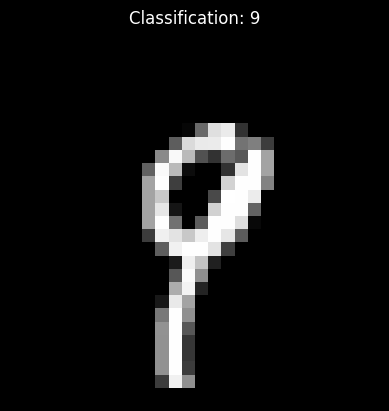

In [3]:
# show examples

random_idx = random.randint(0, len(X_norm) - 1)

# get and reshape image data to 28x28
image = X_norm[random_idx].reshape(28, 28)
label = y[random_idx]

# display the image
plt.imshow(image, cmap='gray')
plt.title(f"Classification: {label}")
plt.axis('off')
plt.show()

In [4]:
# pretraining

train_pct = 0.8
val_pct = 0.1
test_pct = 0.1

num_images = X.shape[0]

# partition the data
train_idx = int(num_images * train_pct)
val_idx = int(num_images * val_pct) + train_idx

X_train = X_norm[:train_idx]
X_val = X_norm[train_idx:val_idx]
X_test = X_norm[val_idx:]

y_train = y[:train_idx]
y_val = y[train_idx:val_idx]
y_test = y[val_idx:]

Y_train_oh = Y[:train_idx]

print(f"X TRAIN:  {X_train.shape}")
print(f"X VAL  :  {X_val.shape}")
print(f"X TEST :  {X_test.shape}")
print()
print(f"y TRAIN:  {y_train.shape}")
print(f"y VAL  :  {y_val.shape}")
print(f"y TEST :  {y_test.shape}")

X TRAIN:  (56000, 784)
X VAL  :  (7000, 784)
X TEST :  (7000, 784)

y TRAIN:  (56000,)
y VAL  :  (7000,)
y TEST :  (7000,)


In [6]:
# define modules, model architecture, loss function

"""
RNN structure:

784 -> 256 -> 128 -> 10
input layer of 784  (28x28 pixels)
2 hidden layers
output layer classifying among 10 classes
"""

# abstract class, like a java interface
class Module(ABC):
    @abstractmethod
    def forward(self, X):
        pass

    @abstractmethod
    def backward(self, dA):
        pass


# layer of neurons
class Layer(Module):
    def __init__(self, n_in, n_out):
        self.W = np.random.randn(n_in, n_out) * np.sqrt(2 / n_in)  # weights
        self.b = np.zeros((1, n_out))  # biases

    def forward(self, X):
        self.input = X
        return X @ self.W + self.b  # fundamental eqn: A = XW + b

    def backward(self, dA):
        dX = dA @ self.W.T
        self.dW = self.input.T @ dA
        self.db = np.sum(dA, axis=0, keepdims=True)
        return dX


# "rectified linear unit" activation function
class ReLU(Module):
    def forward(self, X):
        self.input = X
        return np.maximum(0, X)  # or heaviside step u(x) * x

    def backward(self, dA):
        return dA * (self.input > 0)  # gradient = u(x) * 1


# tanh activation function
class Tanh(Module):
    def forward(self, X):
        self.output = np.tanh(X)
        return self.output
    def backward(self, dA):
        return dA * (1 - self.output**2)  # gradient of tanh


# softmax activation function
class Softmax(Module):
    def forward(self, X):
        X_shifted = X - np.max(X, axis=1, keepdims=True)
        self.input = np.exp(X_shifted) / np.sum(np.exp(X_shifted), axis=1, keepdims=True)
        return self.input
    def backward(self, Y_oh):
        n = self.input.shape[0]
        return (self.input - Y_oh) / n  # self.input means probs here


class FeedForwardNetwork(Module):
    def __init__(self, modules):
        self.modules = modules

    def forward(self, X):
        for module in self.modules:
            X = module.forward(X)
        return X

    # flow tensors backwards
    def backward(self, Y_oh):
        dL = self.modules[-1].backward(Y_oh)  # softmax + loss grad
        for module in reversed(self.modules[:-1]):  # everything else
            dL = module.backward(dL)

    # simple gradient descent
    def update(self, lr):
        for module in self.modules:
            if isinstance(module, Layer):
                module.W -= lr * module.dW  # move in opp. dir of grad
                module.b -= lr * module.db  # descend down gradient

    def grad_descent(self, lr): self.update(lr)  # alias for update

  # similar to torch.zero_grad()
    def zero_cache(self):
        attrs_to_clear = ["input", "output", "dW", "db"]
        for module in self.modules:
            for attr in attrs_to_clear:
                if hasattr(module, attr):
                    setattr(module, attr, None)


# loss function
def cross_entropy_loss(probs, Y_oh):
    probs = np.clip(probs, 1e-15, 1 - 1e-15)
    n = probs.shape[0]
    return -np.sum(Y_oh * np.log(probs)) / n

In [7]:
# initialize model

net = FeedForwardNetwork([
    Layer(784, 256), ReLU(),
    Layer(256, 128), ReLU(),
    Layer(128, 10),  Softmax()
])


EPOCH [1 / 25]:  loss=1.0453,  val_acc=87.3143%,  train_acc=85.8482%
EPOCH [2 / 25]:  loss=0.4567,  val_acc=89.9000%,  train_acc=89.1571%
EPOCH [3 / 25]:  loss=0.3655,  val_acc=90.9857%,  train_acc=90.4393%
EPOCH [4 / 25]:  loss=0.3230,  val_acc=91.7857%,  train_acc=91.3196%
EPOCH [5 / 25]:  loss=0.2954,  val_acc=92.3571%,  train_acc=92.0214%
EPOCH [6 / 25]:  loss=0.2747,  val_acc=92.8429%,  train_acc=92.5500%
EPOCH [7 / 25]:  loss=0.2580,  val_acc=93.3000%,  train_acc=93.0143%
EPOCH [8 / 25]:  loss=0.2438,  val_acc=93.6429%,  train_acc=93.3571%
EPOCH [9 / 25]:  loss=0.2315,  val_acc=94.0143%,  train_acc=93.6000%
EPOCH [10 / 25]:  loss=0.2207,  val_acc=94.2571%,  train_acc=93.8536%
EPOCH [11 / 25]:  loss=0.2110,  val_acc=94.5571%,  train_acc=94.1464%
EPOCH [12 / 25]:  loss=0.2024,  val_acc=94.7286%,  train_acc=94.3911%
EPOCH [13 / 25]:  loss=0.1944,  val_acc=94.8143%,  train_acc=94.6232%
EPOCH [14 / 25]:  loss=0.1871,  val_acc=94.9000%,  train_acc=94.8232%
EPOCH [15 / 25]:  loss=0.1804

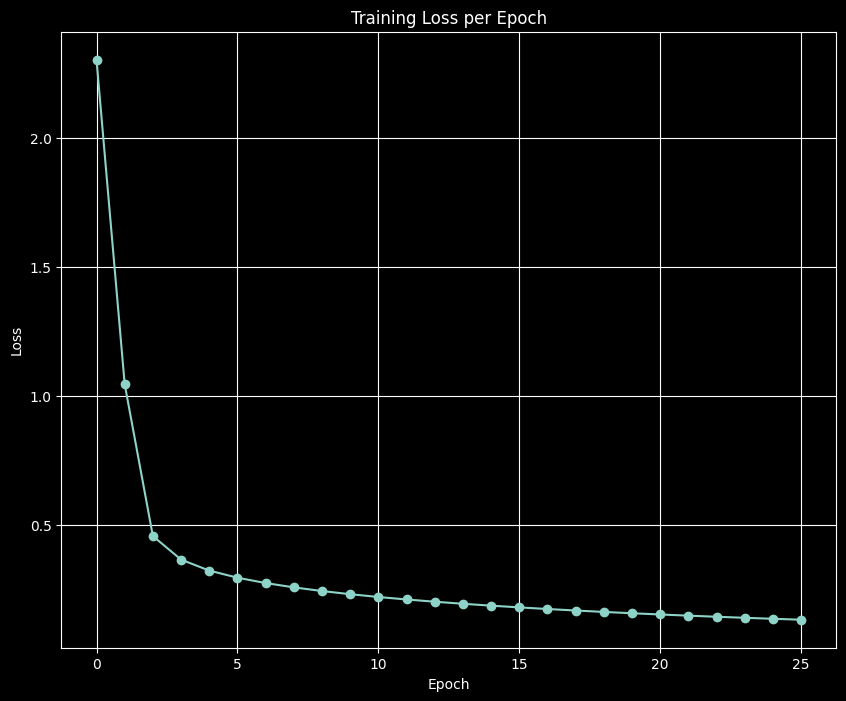

In [8]:
# training

"""
structure of training loop:

shuffle data
split into n-sized batches
for each batch:
  forward pass and get probs
  compute loss
  backprop and compute grads
  update Layer weights and biases
track avg loss and accuracy
"""


# helper function
def run_accuracy(net, X, y):
  probs = net.forward(X)
  acc = np.mean(np.argmax(probs, axis=1) == y)
  net.zero_cache()

  return acc


# training loop
def train(net, lossf, X, y, Y_oh, X_val, y_val, epochs, batch_size, lr):
  # data already shuffled, no need to reshuffle
  num_batches = np.round(X.shape[0] / batch_size).astype(int)
  losses = []

  # times to train through data
  for epoch in range(1,epochs+1):
    epoch_loss = 0.0
    batch_n = 0

    # batching for efficiency, training benefits
    for i in range(0, X.shape[0], batch_size):
      batch_n += 1

      X_batch = X[i:i+batch_size]
      Y_oh_batch = Y_oh[i:i+batch_size]

      probs = net.forward(X_batch)
      loss = lossf(probs, Y_oh_batch)
      net.backward(Y_oh_batch)  # backpropagate
      net.update(lr)  # gradient descent!

      epoch_loss += loss

    epoch_loss /= num_batches
    losses.append(epoch_loss)  # for loss graph

    train_acc = run_accuracy(net=net, X=X, y=y)  # check accuracy
    val_acc = run_accuracy(net=net, X=X_val, y=y_val)  # ensure not over/underfitting

    print(f"EPOCH [{epoch} / {epochs}]:  loss={epoch_loss:.4f},  val_acc={val_acc*100:.4f}%,  train_acc={train_acc*100:.4f}%")

  return losses


loss_curve = train(
    net=net,
    lossf=cross_entropy_loss,
    X=X_train,
    y=y_train,
    Y_oh=Y_train_oh,
    X_val=X_val,
    y_val=y_val,
    epochs=25,
    batch_size=128,
    lr=1e-2
)

# cross-entropy loss on random decisions (i.e., an untrained model)
# is ln(num_labels), so the 0th epoch has loss ln(10)
loss_curve = [np.log(10)] + loss_curve

# plot the loss curve
plt.figure(figsize=(10, 8))
plt.plot(range(0, len(loss_curve)), loss_curve, marker='o')
plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [9]:
# final accuracy tests

test_acc = run_accuracy(net=net, X=X_test, y=y_test)
print(f"\n\nFinished training.  Net:  test_acc={test_acc*100:.4f}%")



Finished training.  Net:  test_acc=96.6000%


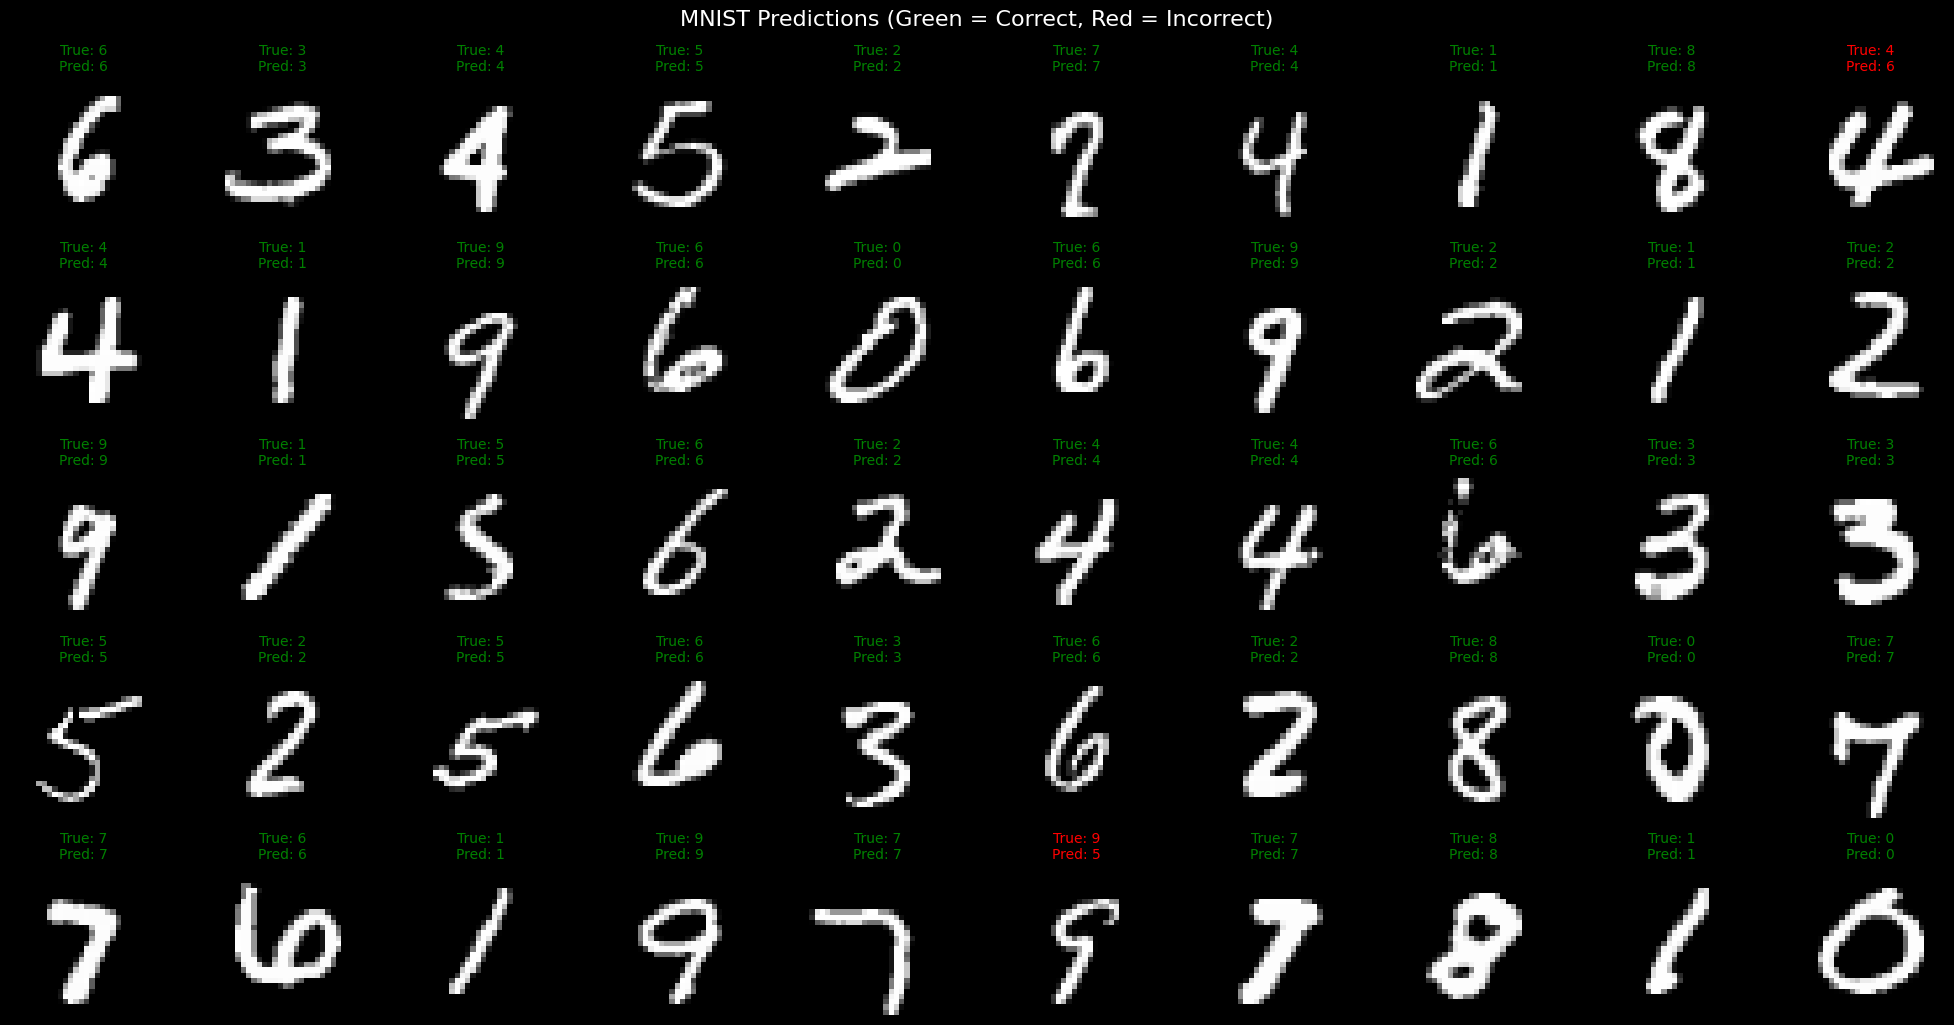

In [16]:
# play with it yourself!

width = 10
height = 5
num_images_to_display = width * height

# randomly select test images + labels
rand_idxs = random.sample(range(len(X_test)), num_images_to_display)
X_sample = X_test[rand_idxs]
y_sample = y_test[rand_idxs]

# predict
probs_sample = net.forward(X_sample)
predictions = np.argmax(probs_sample, axis=1)

plt.figure(figsize=(width * 2, height * 2))
for i in range(num_images_to_display):
    plt.subplot(height, width, i + 1)

    # reshape the image for display
    image = X_sample[i].reshape(28, 28)

    true_label = y_sample[i]
    predicted_label = predictions[i]

    # determine color based on correctness
    color = 'green' if true_label == predicted_label else 'red'

    plt.imshow(image, cmap='gray')
    plt.title(f"True: {true_label}\nPred: {predicted_label}", color=color, fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.suptitle('MNIST Predictions (Green = Correct, Red = Incorrect)', y=1.02, fontsize=16)
plt.show()